## Required files (in the same folder as the notebook)
- `transactions.csv`: transactions (time series), intentionally *messy*

> The datasets intentionally include: missing values, duplicates, dirty strings, mixed date formats, amounts as text, etc.  
> The goal: learn to clean data **without panicking**, then produce insights.



## Table of contents
1. Load + first exploration
2. Dates: `pd.to_datetime` + `.dt`
3. Time series: `set_index`, `resample`, `rolling`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Storytelling & Time Series (transactions)

## 1) Load the dataset + first exploration

### Why start here?
Before “coding just to code”, you want to answer:
1) **What do we have?** (columns, volume)  
2) **Is it reliable?** (types, NAs, duplicates)  
3) **Which story angle?** (time trends, categories, anomalies)

### What is intentionally “dirty” in `transactions.csv`
- `timestamp`: mix of ISO + French formats + a few invalid dates
- `amount_raw`: sometimes float, sometimes string `"12,34 €"`, sometimes empty

### Common mistakes
- Jumping into `groupby` before validating types
- Confusing empty strings (`""`) with `NaN`
- Forgetting that `read_csv` “guesses” types → sometimes wrong (and expensive)


In [2]:
# "Naive" read (on purpose): Pandas will INFER dtypes.
tx = pd.read_csv("transactions.csv")
tx.head()


,transaction_id,customer_id,timestamp,merchant,category,channel,city,country,payment_method,status,amount_raw,currency,coupon_code,device,is_refund,notes
0,TX4672890857,1334,2024-01-17 05:50:53,H&M,Travel,online,París,FR,bank_transfer,completed,13.21,EUR,NaN,iOS,0,NaN
1,TX5712538099,1053,2024-05-20 20:38:23,APPLE STORE,Entertainment,in_store,Bordeaux,ES,apple_pay,completed,23.62,EUR,NaN,Android,0,duplicate
2,TX6879868711,1048,2024-04-29 03:10:05,Deliveroo,Entertainment,online,Paris,FR,paypal,completed,19.7,EUR,NaN,Android,0,NaN
3,TX7868258381,1347,2024-03-20 21:01:15,fnac,Subscription,online,Montpellier,FR,card,completed,56.8,EUR,freeship,iOS,0,NaN
4,TX9718829857,1438,2024-03-19 19:24:37,UBER *TRIP,Utilities,online,Paris,FR,card,completed,43.49,EUR,vip20,NaN,0,NaN



### `.shape` vs `.info()`

- `tx.shape` → size (fast, doesn’t deeply scan every column)
- `tx.info()` → types + non-null counts + memory (excellent diagnostic)

⚠️ Pitfall: `shape` is an attribute → no parentheses.


In [3]:
tx.shape

(5535, 16)

In [4]:
tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5535 entries, 0 to 5534
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  5535 non-null   object
 1   customer_id     5535 non-null   int64 
 2   timestamp       5535 non-null   object
 3   merchant        5464 non-null   object
 4   category        5482 non-null   object
 5   channel         5535 non-null   object
 6   city            5479 non-null   object
 7   country         5535 non-null   object
 8   payment_method  5535 non-null   object
 9   status          5535 non-null   object
 10  amount_raw      5298 non-null   object
 11  currency        5535 non-null   object
 12  coupon_code     2068 non-null   object
 13  device          5194 non-null   object
 14  is_refund       5535 non-null   int64 
 15  notes           1728 non-null   object
dtypes: int64(2), object(14)
memory usage: 692.0+ KB



## 2) Dates: `pd.to_datetime` + `.dt` (the foundation of time series)

### Why it matters
Everything “time storytelling” depends on dates:
- `resample` / `rolling` / `dt.day_name()` only work on datetime
- if parsing fails, you create `NaT` and lose rows

### How does `pd.to_datetime` work? (mental model)
- It tries to parse each value into a datetime
- `errors="coerce"`: if it fails → `NaT` (instead of crashing)
- `dayfirst=True`: resolves ambiguity like `10/03/2024` (March 10 vs Oct 3)

### Common mistakes / pitfalls
- Forgetting `dayfirst=True` with French-style dates
- Not inspecting `NaT`
- Dropping rows without knowing how many you lose


In [5]:
# Robust parsing: invalid => NaT (we prefer NaT over an exception)
tx["timestamp_dt"] = pd.to_datetime(tx["timestamp"], errors="coerce", dayfirst=True)

tx[["timestamp", "timestamp_dt"]].sample(10, random_state=1)


/var/folders/dr/m9v4shms079d9s6z6c8cg57m0000gn/T/ipykernel_23241/4049546145.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  tx["timestamp_dt"] = pd.to_datetime(tx["timestamp"], errors="coerce", dayfirst=True)


,timestamp,timestamp_dt
1810,2024-02-30 10:00:00,NaT
3810,2024-03-10 15:25:46,2024-03-10 15:25:46
1907,2024-01-07 15:38:05,2024-01-07 15:38:05
1724,2024-05-22 11:58:10,2024-05-22 11:58:10
1963,2024-05-28 16:15:39,2024-05-28 16:15:39
1807,2024-01-17 08:25:33,2024-01-17 08:25:33
4536,2024-04-18 20:49:39,2024-04-18 20:49:39
644,2024-05-20 04:37:38,2024-05-20 04:37:38
4819,2024-06-26 09:00:38,2024-06-26 09:00:38
116,2024-01-07 18:45:42,2024-01-07 18:45:42



### Measure the “damage”: how many invalid dates?

It’s a signal: if 30% are `NaT`, you need to understand why.


In [6]:
invalid_rate = tx["timestamp_dt"].isna().mean()
invalid_rate

np.float64(0.23089430894308943)


### Inspect problematic rows

This helps you decide:
- fix some values (if possible)
- drop
- or impute (rarely recommended for timestamps)


In [7]:
tx.loc[tx["timestamp_dt"].isna(), ["transaction_id", "timestamp"]].head(15)

,transaction_id,timestamp
6,TX4203463325,16/01/2024 15:24:37
7,TX5812244535,01/13/2024 12:00
8,TX2943280120,06/02/2024 16:01:07
9,TX9718778180,18/01/2024 03:21:59
10,TX5818986390,05/04/2024 19:39:36
15,TX1672395281,not_a_date
20,TX6443849902,01/04/2024 01:32:13
26,TX4445898540,14/03/2024 05:44:44
31,TX2800036200,11/02/2024 08:34:43
33,TX2624356240,10/04/2024 22:25:34



Here we **drop** invalid rows to keep a simple pipeline.

Common mistake: forgetting `.copy()` after filtering/dropping.  
Without `.copy()`, assignment can behave surprisingly (SettingWithCopy).


In [8]:
tx = tx.dropna(subset=["timestamp_dt"]).copy()
tx.shape

(4257, 17)


## 2) `.dt`: extract time features (vectorized)

### Why?
It lets you:
- group by month (`month`)
- analyze patterns by weekday (`weekday`)
- analyze activity by hour (`hour`)
- build features for ML later

### How it works
When your column is datetime, `tx["timestamp_dt"].dt.<...>` applies the operation **to the whole column** (vectorized).  
It’s faster and simpler than `apply(lambda ...)`.

### Common mistakes
- Using `.dt` on a non-datetime column → error
- `.dt.day_name()` depends on locale, but is fine here


In [9]:
tx["date"] = tx["timestamp_dt"].dt.date

# to_period("M") creates a "monthly period" (great for groupby)
tx["month"] = tx["timestamp_dt"].dt.to_period("M").astype(str)

tx["weekday"] = tx["timestamp_dt"].dt.day_name()
tx["hour"] = tx["timestamp_dt"].dt.hour

tx[["timestamp_dt", "month", "weekday", "hour"]].head()


,timestamp_dt,month,weekday,hour
0,2024-01-17 05:50:53,2024-01,Wednesday,5
1,2024-05-20 20:38:23,2024-05,Monday,20
2,2024-04-29 03:10:05,2024-04,Monday,3
3,2024-03-20 21:01:15,2024-03,Wednesday,21
4,2024-03-19 19:24:37,2024-03,Tuesday,19



## 3) Time series: `set_index` + `resample` + `rolling`

### Why `set_index`?
Many Pandas time-series tools expect a datetime index:
- `resample("D")`, `rolling("7D")`, `asfreq`, etc.

### `resample` (mental model)
It’s like a time-based groupby:
- choose a frequency (D, W, M…)
- apply an aggregation (sum, mean, count…)

### `rolling` (mental model)
Moving average:
- fixed window (e.g., 7 days)
- smooths noise

### Common mistakes
- forgetting to sort the time index (`sort_index()`)
- `sum()` on a 100% NaN series → 0 or NaN depending on parameters → here we use `min_count=1`


In [10]:
tx_ts = tx.set_index("timestamp_dt").sort_index()

# Daily net revenue (remarque : min_count=1 -> si aucun point, on garde NaN)
daily_refund = tx_ts["is_refund"].resample("D").sum(min_count=1)

# Daily count (nb de transactions par jour)
daily_count = tx_ts["transaction_id"].resample("D").count()

daily_refund.head(), daily_count.head()

(timestamp_dt
 2024-01-01    1
 2024-01-02    0
 2024-01-03    1
 2024-01-04    2
 2024-01-05    0
 Freq: D, Name: is_refund, dtype: int64,
 timestamp_dt
 2024-01-01    27
 2024-01-02    19
 2024-01-03    18
 2024-01-04    24
 2024-01-05    24
 Freq: D, Name: transaction_id, dtype: int64)

In [11]:
daily_refund_7d = daily_refund.rolling(7, min_periods=1).mean()
daily_refund_7d.head()

timestamp_dt
2024-01-01    1.000000
2024-01-02    0.500000
2024-01-03    0.666667
2024-01-04    1.000000
2024-01-05    0.800000
Freq: D, Name: is_refund, dtype: float64


### Visualize: raw vs smoothed daily refunds

> We use Matplotlib (not seaborn) to keep things minimal and portable.


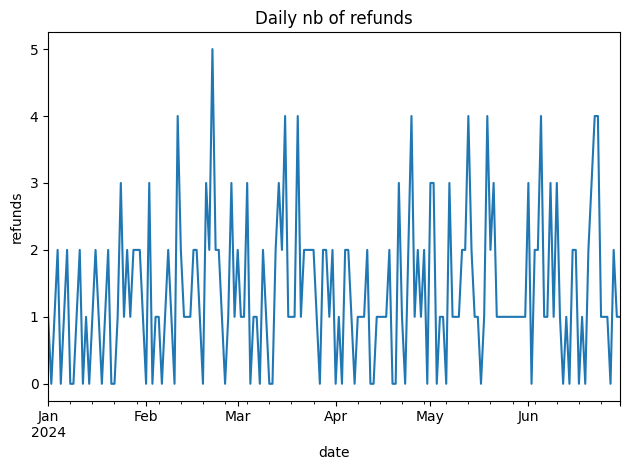

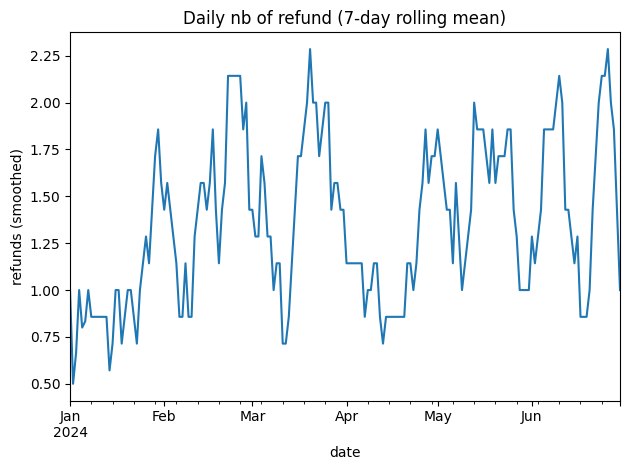

In [12]:
plt.figure()
daily_refund.plot(title="Daily nb of refunds")
plt.xlabel("date"); plt.ylabel("refunds")
plt.tight_layout(); plt.show()

plt.figure()
daily_refund_7d.plot(title="Daily nb of refund (7-day rolling mean)")
plt.xlabel("date"); plt.ylabel("refunds (smoothed)")
plt.tight_layout(); plt.show()